In [148]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 14,            # default text size
    "axes.labelsize": 14,       # x/y labels
    "axes.labelweight": "normal",
    "xtick.labelsize": 10,      # x tick labels
    "ytick.labelsize": 10,      # y tick labels
    "legend.fontsize": 10,      # legend text
    "lines.linewidth": 1,        # thicker plot lines
    "grid.linewidth": 1.1
})

In [65]:
measurement_data = np.loadtxt("data.txt")

unique_concentration_values = np.unique(measurement_data[:,0])
data_groups = {val: measurement_data[measurement_data[:,0] == val] for val in unique_concentration_values}

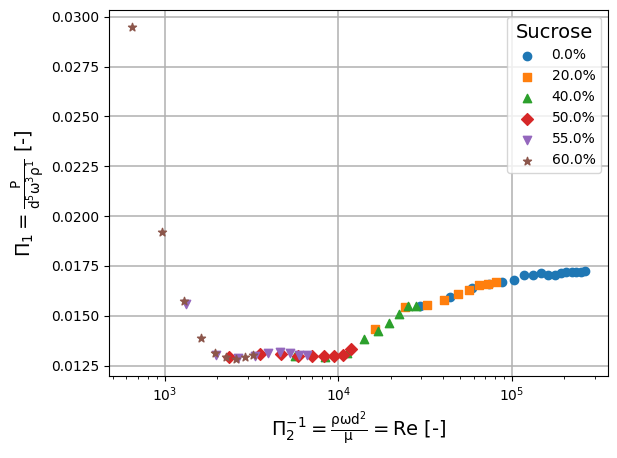

In [169]:
D = 53 * 10**-3
markers = ['o', 's', '^', 'D', 'v', '*']

fig, ax1 = plt.subplots()

ax1.set_xlabel(r"$\Pi_2 ^{-1} = \mathrm{\frac{\rho \omega d^2}{\mu}} = \text{Re}$ [-]")
ax1.set_ylabel(r"$\Pi_1 = \frac{\mathrm{P}}{\mathrm{d}^5 \mathrm{\omega}^3 \mathrm{\rho}^1}$ [-]")
ax1.set_xscale("log")


for i, val in enumerate(unique_concentration_values):
    
    data = data_groups[val]
    
    sucrose_concentration, rho, mu, rpm, torque = data[:,0], data[:,1], data[:,2], data[:,3], data[:,4]
    
    angular_frequency = rpm * 2 * np.pi / 60
    
    PI_1 = torque * angular_frequency / D**5 / angular_frequency**3 / rho
    
    PI_2 = mu / D**2 / angular_frequency / rho
    
    ax1.scatter(PI_2**-1, PI_1, marker=markers[i], label=f"{val}%", zorder=3)

ax1.grid()
ax1.legend(title="Sucrose")
plt.tight_layout()
plt.savefig("Piplot.pdf", dpi=300)

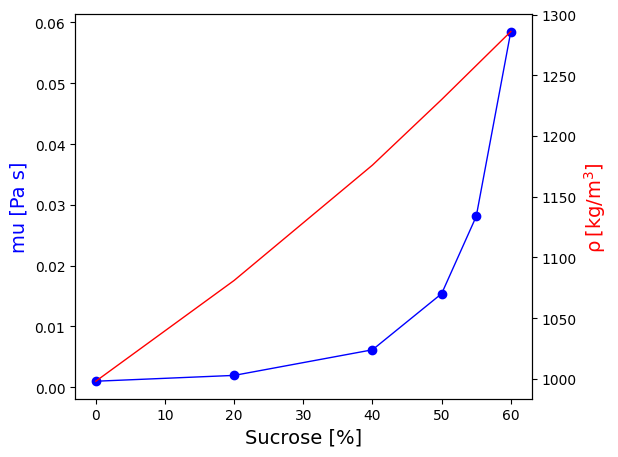

In [168]:
fig, ax1 = plt.subplots()

ax1.plot(unique_concentration_values, [data_groups[var][:, 2][0] for var in unique_concentration_values], "bo-",label="mu")

ax1.set_xlabel("Sucrose [%]")
ax1.set_ylabel("mu [Pa s]", color="b")
ax2 = ax1.twinx()

ax2.plot(unique_concentration_values, [data_groups[var][:, 1][0] for var in unique_concentration_values], label="rho", color="r")
ax2.set_ylabel(r"$\mathrm{\rho \: [kg / m^3]} $", color="r")

plt.tight_layout()
plt.savefig("sucrose.pdf", dpi=300)

In [ ]:
x = 5

print(id(x))

c = "5"

print(id(c))

x = [1, 2, 3]

140718630451768
140718630512792
1828662555712
1828715570496
